For all problems, the heat rod model is imported from homework 1 (filename heat_rod.py). I'm attaching heat_rod.py code in the Appendix, without the pages assigned for each problem, for clarity.

# 1.1

Shape of observations: (15,)
Initial test - r(q0, q0) = 1.000000

Running Metropolis algorithm for 1000 iterations...
Proposal distribution: N(q_prev, D) with D = diag([0.01, 2e-10])
Running Metropolis-Hastings MCMC...
  Completed 200/1000 iterations, acceptance rate: 0.719
  Completed 400/1000 iterations, acceptance rate: 0.759
  Completed 600/1000 iterations, acceptance rate: 0.783
  Completed 800/1000 iterations, acceptance rate: 0.796
  Completed 1000/1000 iterations, acceptance rate: 0.799

Final acceptance rate: 0.799

Computing posterior values for MAP estimate...

PROBLEM 1.1 RESULTS

MAP Estimate (q_MAP):
  Φ = -17.560427 W/cm²
  h = 0.001814 W/cm²/°C
  π(υ|q_MAP)π0(q_MAP) = 5.61e-03

Posterior Distribution π(q|υ) Summary:
Φ:
  Mean = -18.395988 W/cm²
  Std  = 0.747602 W/cm²
  95% CI = [-19.464980, -15.928881]

h:
  Mean = 1.916442e-03 W/cm²/°C
  Std  = 4.574893e-05 W/cm²/°C
  95% CI = [1.836325e-03, 2.018715e-03]


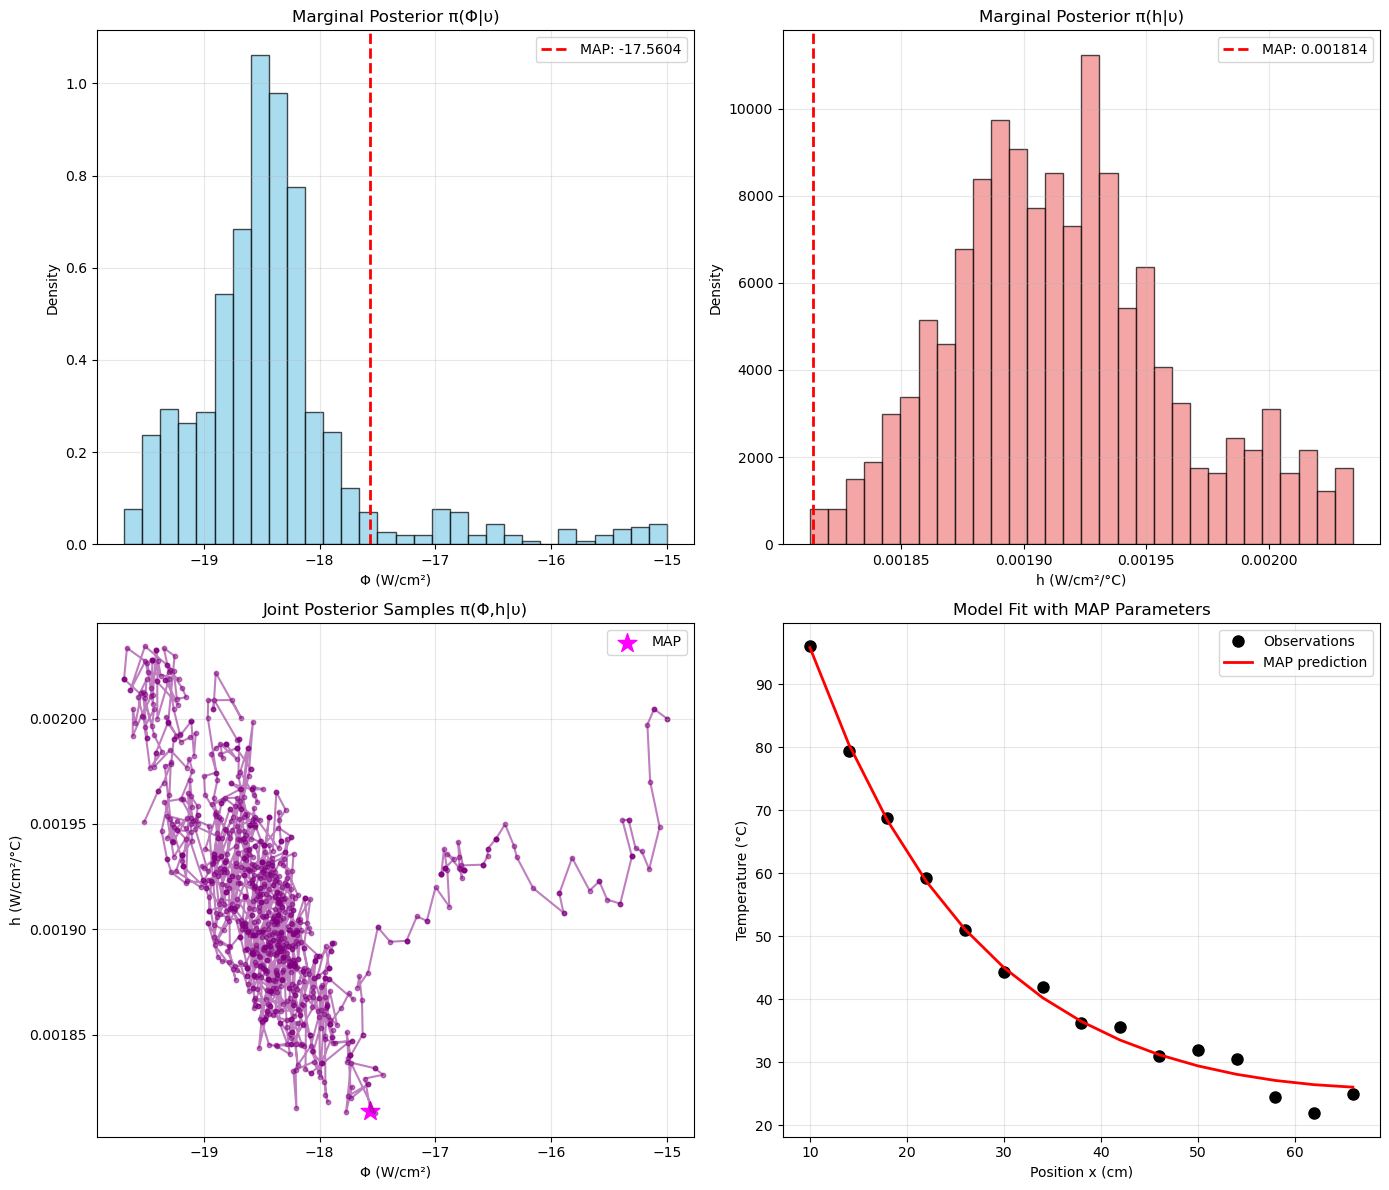


Results saved to 'problem1.1_results.npz'


In [4]:
import os, sys, numpy as np, matplotlib.pyplot as plt
sys.path.append('../hw1')
import heat_rod as hr
from mcmc import *
from scipy.io import loadmat

data = loadmat("HW06_Problem1.mat")
samples, q_map, posterior_values, acceptance_rate = run_metropolis_for_heat_equation()

# Save results
np.savez('problem1.1_results.npz',
            samples=samples,
            q_map=q_map,
            posterior_values=posterior_values,
            acceptance_rate=acceptance_rate)

print(f"\nResults saved to 'problem1.1_results.npz'")

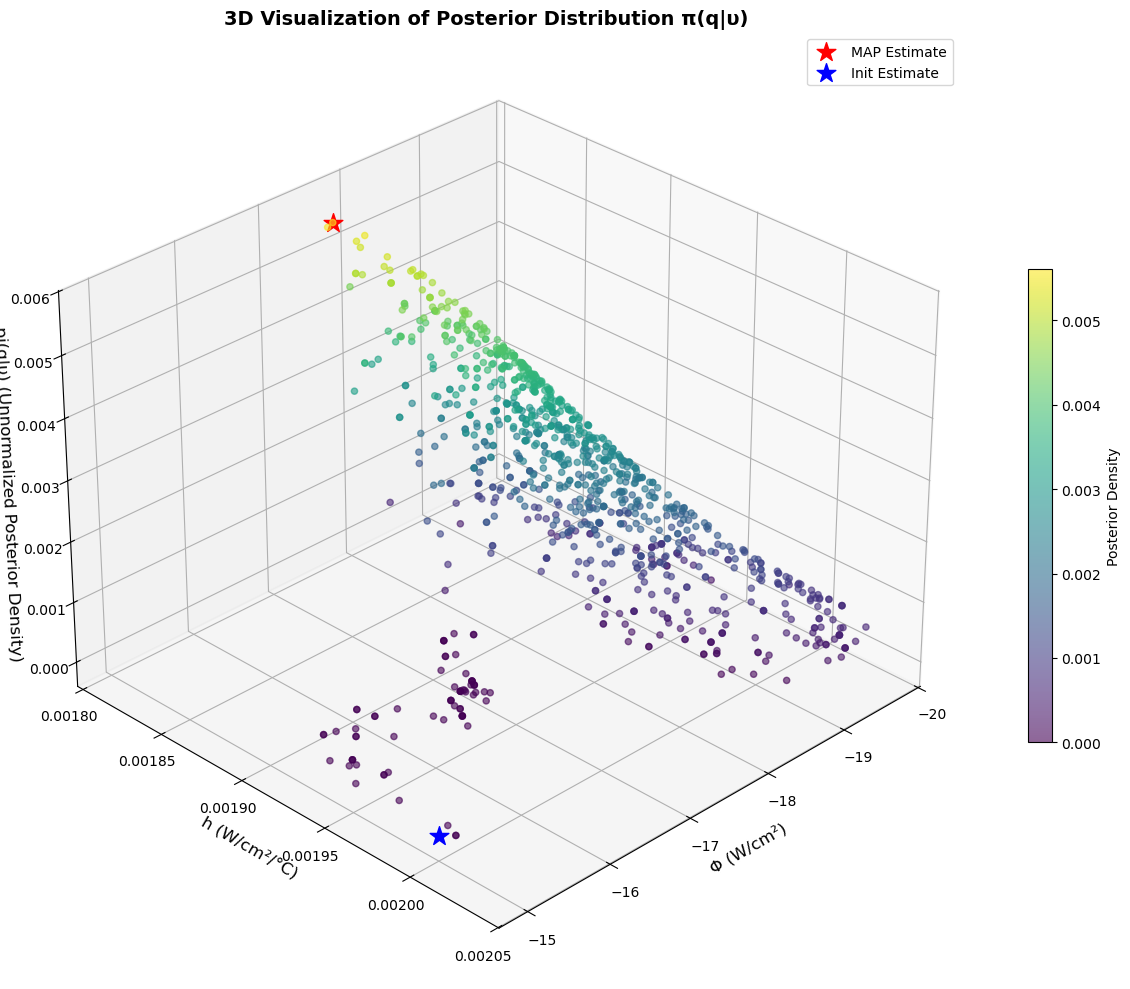

In [5]:
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(samples[:, 0], samples[:, 1], posterior_values, 
                     c=posterior_values, cmap='viridis', 
                     s=20, alpha=0.6, marker='o')

# Mark the MAP estimate
map_idx = np.argmax(posterior_values)
ax.scatter([samples[map_idx, 0]], [samples[map_idx, 1]], [posterior_values[map_idx]], 
           color='red', s=200, marker='*', label=f'MAP Estimate')

ax.scatter([samples[0, 0]], [samples[0, 1]], [posterior_values[0]], 
           color='blue', s=200, marker='*', label=f'Init Estimate')

# Add labels and title
ax.set_xlabel('Φ (W/cm²)', fontsize=12)
ax.set_ylabel('h (W/cm²/°C)', fontsize=12)
ax.set_zlabel('pi(q|υ) (Unnormalized Posterior Density)', fontsize=12)
ax.set_title('3D Visualization of Posterior Distribution π(q|υ)', fontsize=14, fontweight='bold')

# Add colorbar
cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=20)
cbar.set_label('Posterior Density', fontsize=10)

# Add legend
ax.legend()

# Set viewing angle for better initial view
ax.view_init(elev=30, azim=45)

plt.tight_layout()
plt.savefig('posterior_3d_scatter.png', dpi=150)
plt.show()

In [6]:
max(posterior_values)


np.float64(0.005609520242829489)

$q_{MAP} = [ Φ = -17.56 W/cm²,  h = 0.0018 W/cm²/°C]$

$\pi(q_{MAP}|\nu) \approx 0.0056$ 
# 1.2
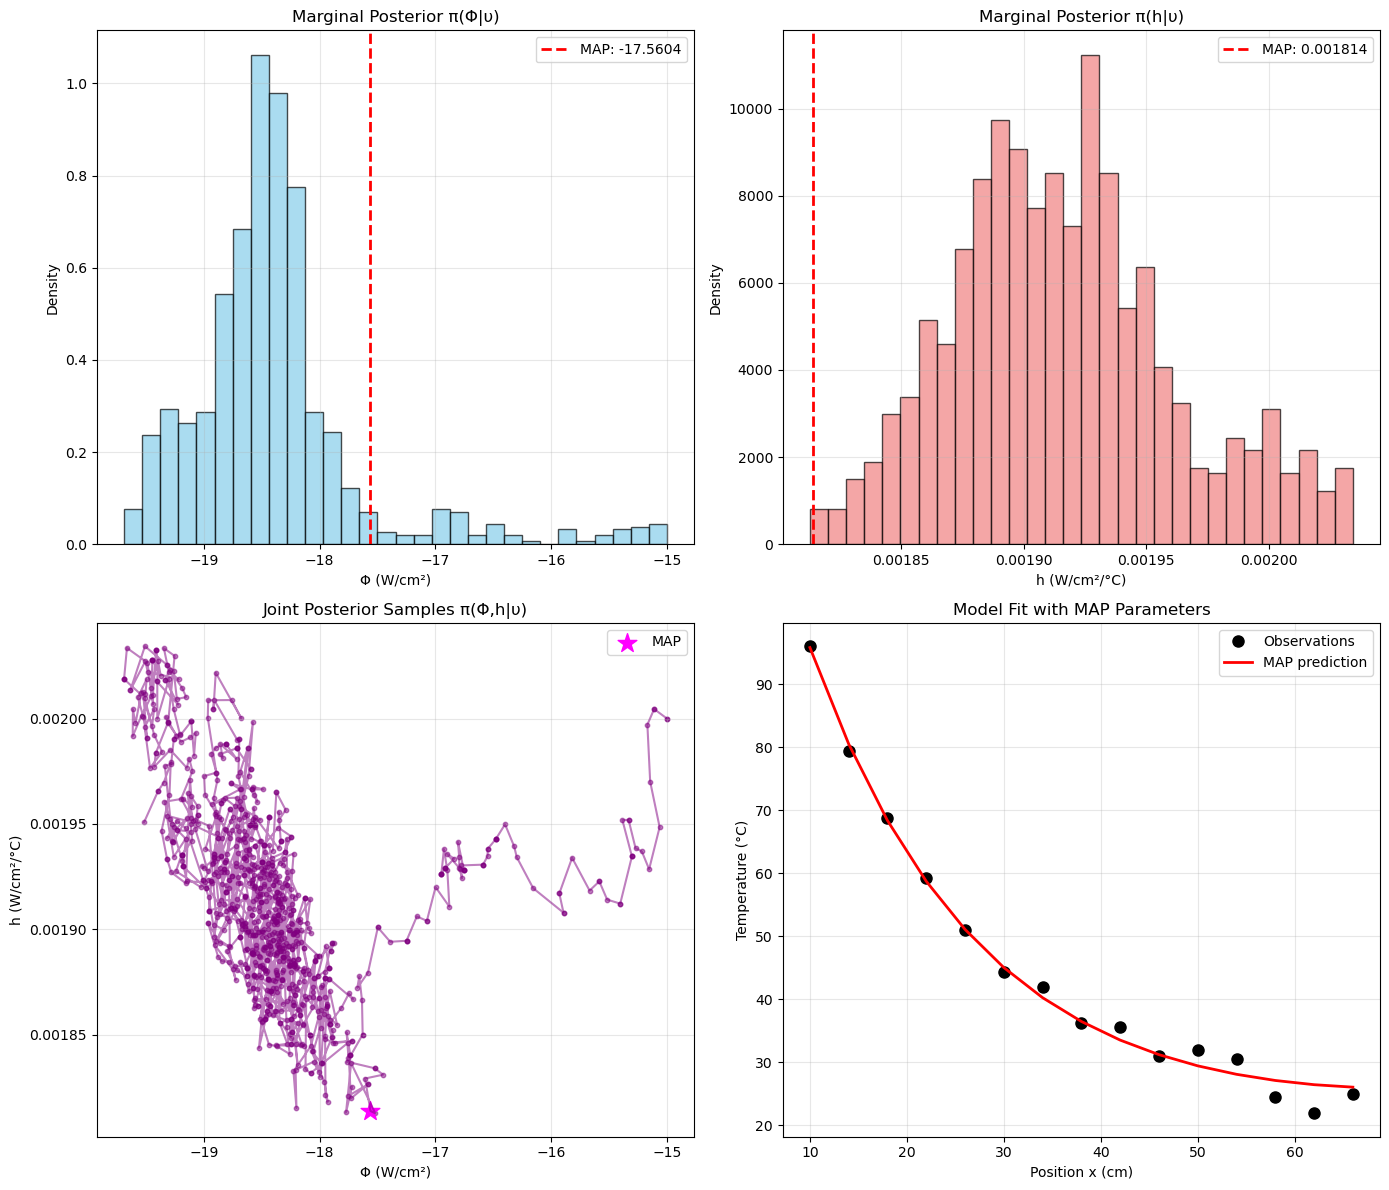
After burn-in, the chain gradually reaches a stationary distribution, but that does not mean the samples are independent (i.i.d).  An MCMC chain satisfies the Markov property,
$$
q^{(k+1)} \sim P(\,\cdot \mid q^{(k)}\,),
$$
so each sample depends directly on the previous one. Even after convergence to the target distribution,
$$
q^{(k)} \sim \pi(q),
$$
the samples are identically distributed (after burn-in) but not independent. In particular, there is generally nonzero serial correlation,
$$
\operatorname{Cov}\!\left(q^{(k)}, q^{(k+1)}\right) \neq 0.
$$
Thus, after sufficient burn-in we have draws from the correct stationary distribution $\pi(q)$, but that does not mean $q^{(k)}$ and $q^{(k+1)}$ are independent, identically distributed. 

The chain retains autocorrelation because of its sequential construction. This matters because correlated samples reduce the effective sample size (ESS), so $\text{ESS} < N$, and variance estimates must account for autocorrelation. Thinning is can be used to reduce correlation (e.g., save only the $r^{th}$ sample to minimize correlation between samples). Thus, burn-in guarantees convergence to the stationary distribution, but it does not imply independence or i.i.d. samples; MCMC produces correlated draws from the correct (of course approximated) target distribution (eventually).


# 1.3
Acceptance ratio = 0.799 (near/at 1000/1000 sample)

# 1.4
Large D

Shape of observations: (15,)
Initial test - r(q0, q0) = 1.000000

Running Metropolis algorithm for 1000 iterations...
Proposal distribution: N(q_prev, D) with D = diag([10.0, 2.0000000000000002e-07])
Running Metropolis-Hastings MCMC...
  Completed 200/1000 iterations, acceptance rate: 0.060
  Completed 400/1000 iterations, acceptance rate: 0.063
  Completed 600/1000 iterations, acceptance rate: 0.052
  Completed 800/1000 iterations, acceptance rate: 0.054
  Completed 1000/1000 iterations, acceptance rate: 0.049

Final acceptance rate: 0.049

Computing posterior values for MAP estimate...

PROBLEM 1.1 RESULTS

MAP Estimate (q_MAP):
  Φ = -17.719167 W/cm²
  h = 0.001837 W/cm²/°C
  π(υ|q_MAP)π0(q_MAP) = 5.03e-03

Posterior Distribution π(q|υ) Summary:
Φ:
  Mean = -18.092433 W/cm²
  Std  = 1.612962 W/cm²
  95% CI = [-23.436418, -15.978914]

h:
  Mean = 1.860009e-03 W/cm²/°C
  Std  = 1.514691e-04 W/cm²/°C
  95% CI = [1.647691e-03, 2.445395e-03]


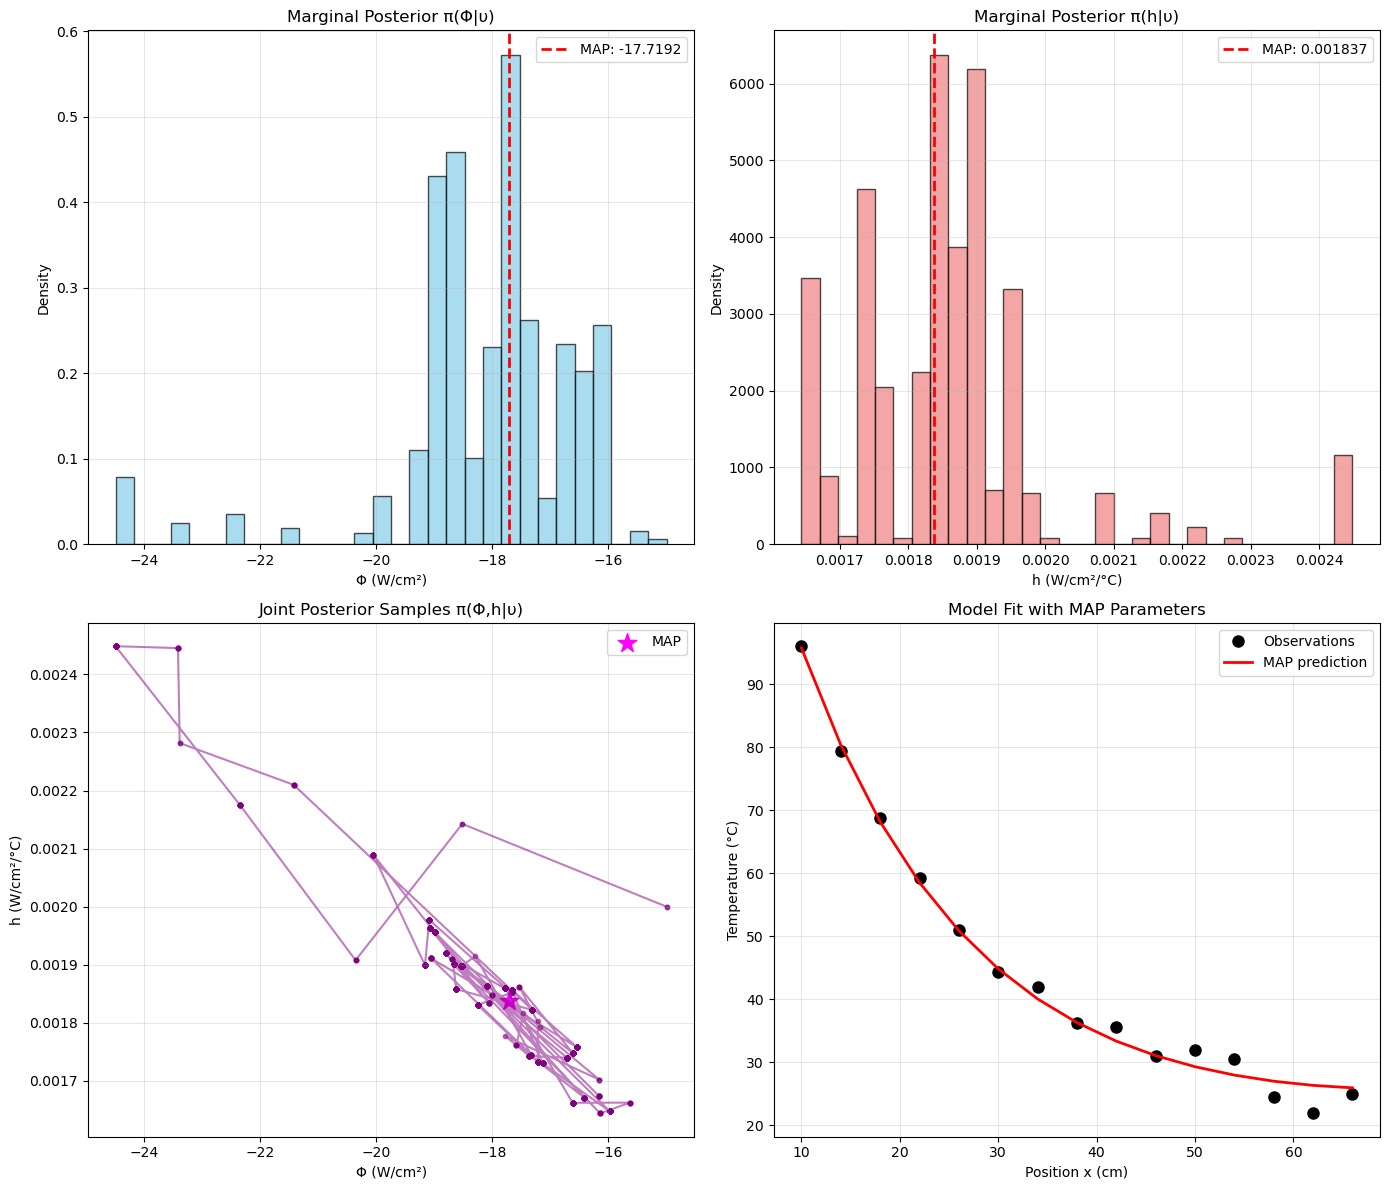

In [7]:
d2 = np.array([[1e-2, 0],
                    [0, 2e-10]]) * 1000
samples, q_map, posterior_values, acceptance_rate = run_metropolis_for_heat_equation(D = d2)

# Save results
np.savez('problem1.4_large_D.npz',
            samples=samples,
            q_map=q_map,
            posterior_values=posterior_values,
            acceptance_rate=acceptance_rate)



Small D

Shape of observations: (15,)
Initial test - r(q0, q0) = 1.000000

Running Metropolis algorithm for 1000 iterations...
Proposal distribution: N(q_prev, D) with D = diag([1e-05, 2e-13])
Running Metropolis-Hastings MCMC...
  Completed 200/1000 iterations, acceptance rate: 0.905
  Completed 400/1000 iterations, acceptance rate: 0.927
  Completed 600/1000 iterations, acceptance rate: 0.927
  Completed 800/1000 iterations, acceptance rate: 0.935
  Completed 1000/1000 iterations, acceptance rate: 0.932

Final acceptance rate: 0.932

Computing posterior values for MAP estimate...

PROBLEM 1.1 RESULTS

MAP Estimate (q_MAP):
  Φ = -15.322028 W/cm²
  h = 0.002006 W/cm²/°C
  π(υ|q_MAP)π0(q_MAP) = 6.64e-41

Posterior Distribution π(q|υ) Summary:
Φ:
  Mean = -15.159361 W/cm²
  Std  = 0.082691 W/cm²
  95% CI = [-15.315041, -15.010574]

h:
  Mean = 2.006650e-03 W/cm²/°C
  Std  = 2.725994e-06 W/cm²/°C
  95% CI = [2.000325e-03, 2.012206e-03]


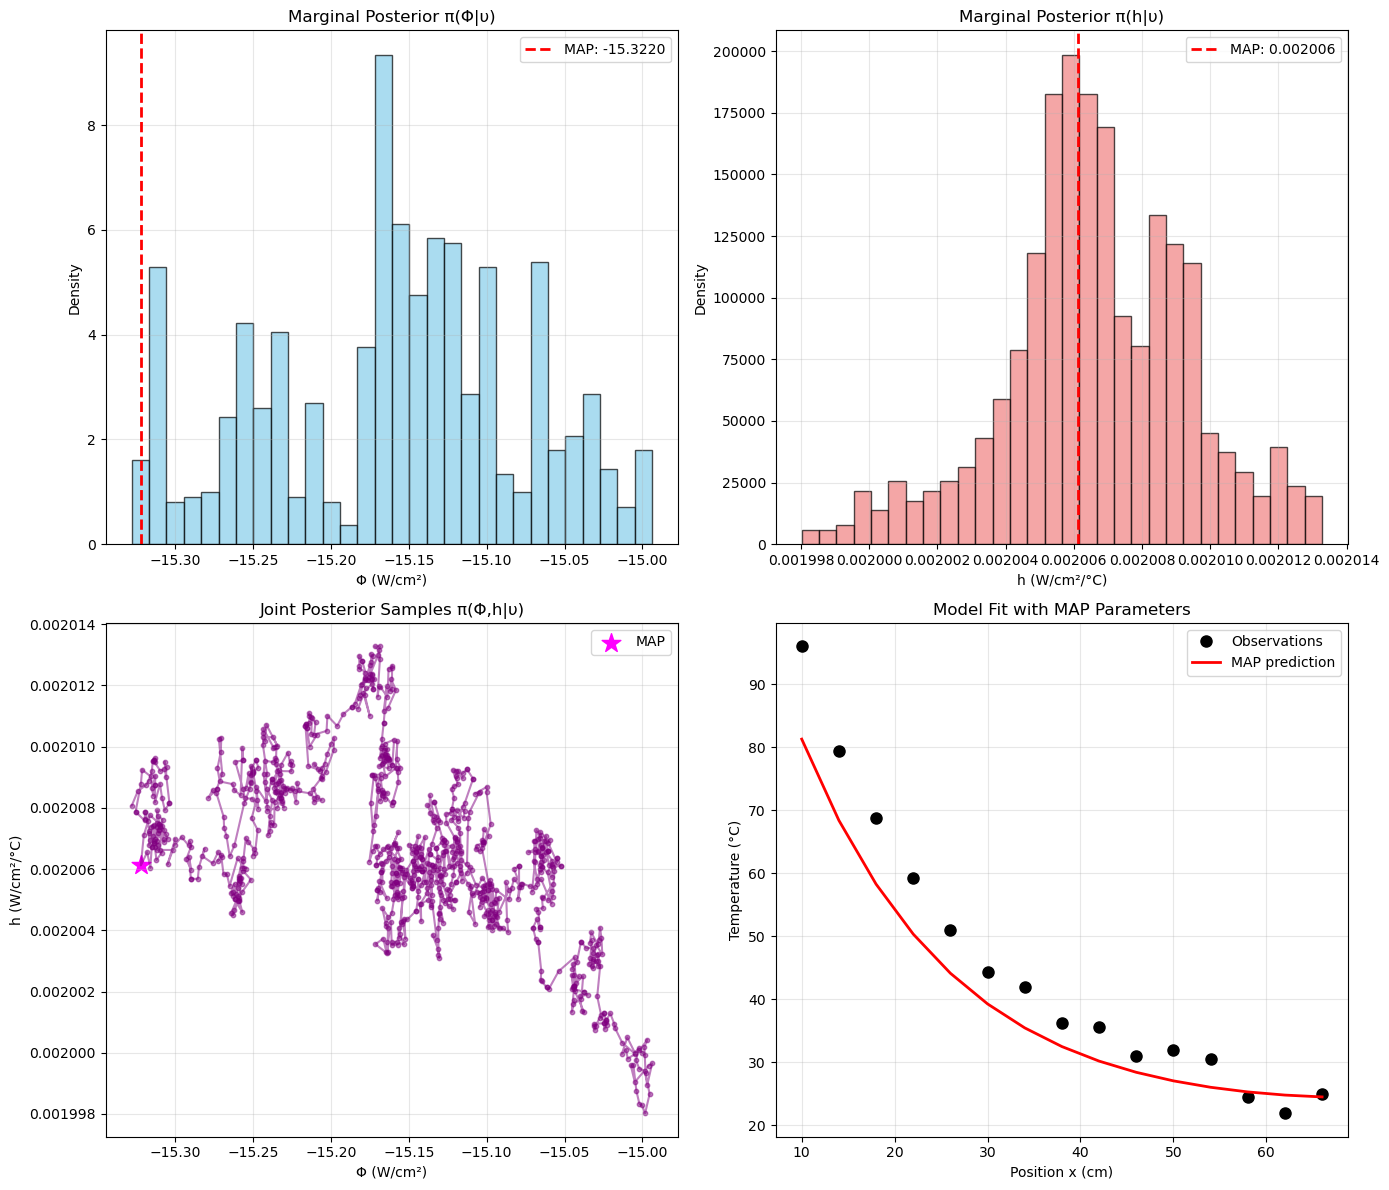

In [8]:

d3 = np.array([[1e-2, 0],
                    [0, 2e-10]]) / 1000
samples, q_map, posterior_values, acceptance_rate = run_metropolis_for_heat_equation(D = d3)

# Save results
np.savez('problem1.4_small_D.npz',
            samples=samples,
            q_map=q_map,
            posterior_values=posterior_values,
            acceptance_rate=acceptance_rate)


Off-Diagonal

Shape of observations: (15,)
Initial test - r(q0, q0) = 1.000000

Running Metropolis algorithm for 1000 iterations...
Proposal distribution: N(q_prev, D) with D = diag([0.01, 2e-10])
Running Metropolis-Hastings MCMC...
  Completed 200/1000 iterations, acceptance rate: 0.362
  Completed 400/1000 iterations, acceptance rate: 0.311
  Completed 600/1000 iterations, acceptance rate: 0.294


/home/mili/ase379l/hw6/mcmc.py:154: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  return np.random.multivariate_normal(q_current, D)


  Completed 800/1000 iterations, acceptance rate: 0.293
  Completed 1000/1000 iterations, acceptance rate: 0.284

Final acceptance rate: 0.284

Computing posterior values for MAP estimate...

PROBLEM 1.1 RESULTS

MAP Estimate (q_MAP):
  Φ = -15.657959 W/cm²
  h = 0.001632 W/cm²/°C
  π(υ|q_MAP)π0(q_MAP) = 1.30e-03

Posterior Distribution π(q|υ) Summary:
Φ:
  Mean = -15.533098 W/cm²
  Std  = 0.077003 W/cm²
  95% CI = [-15.651538, -15.386582]

h:
  Mean = 1.618345e-03 W/cm²/°C
  Std  = 3.463688e-05 W/cm²/°C
  95% CI = [1.567229e-03, 1.666204e-03]


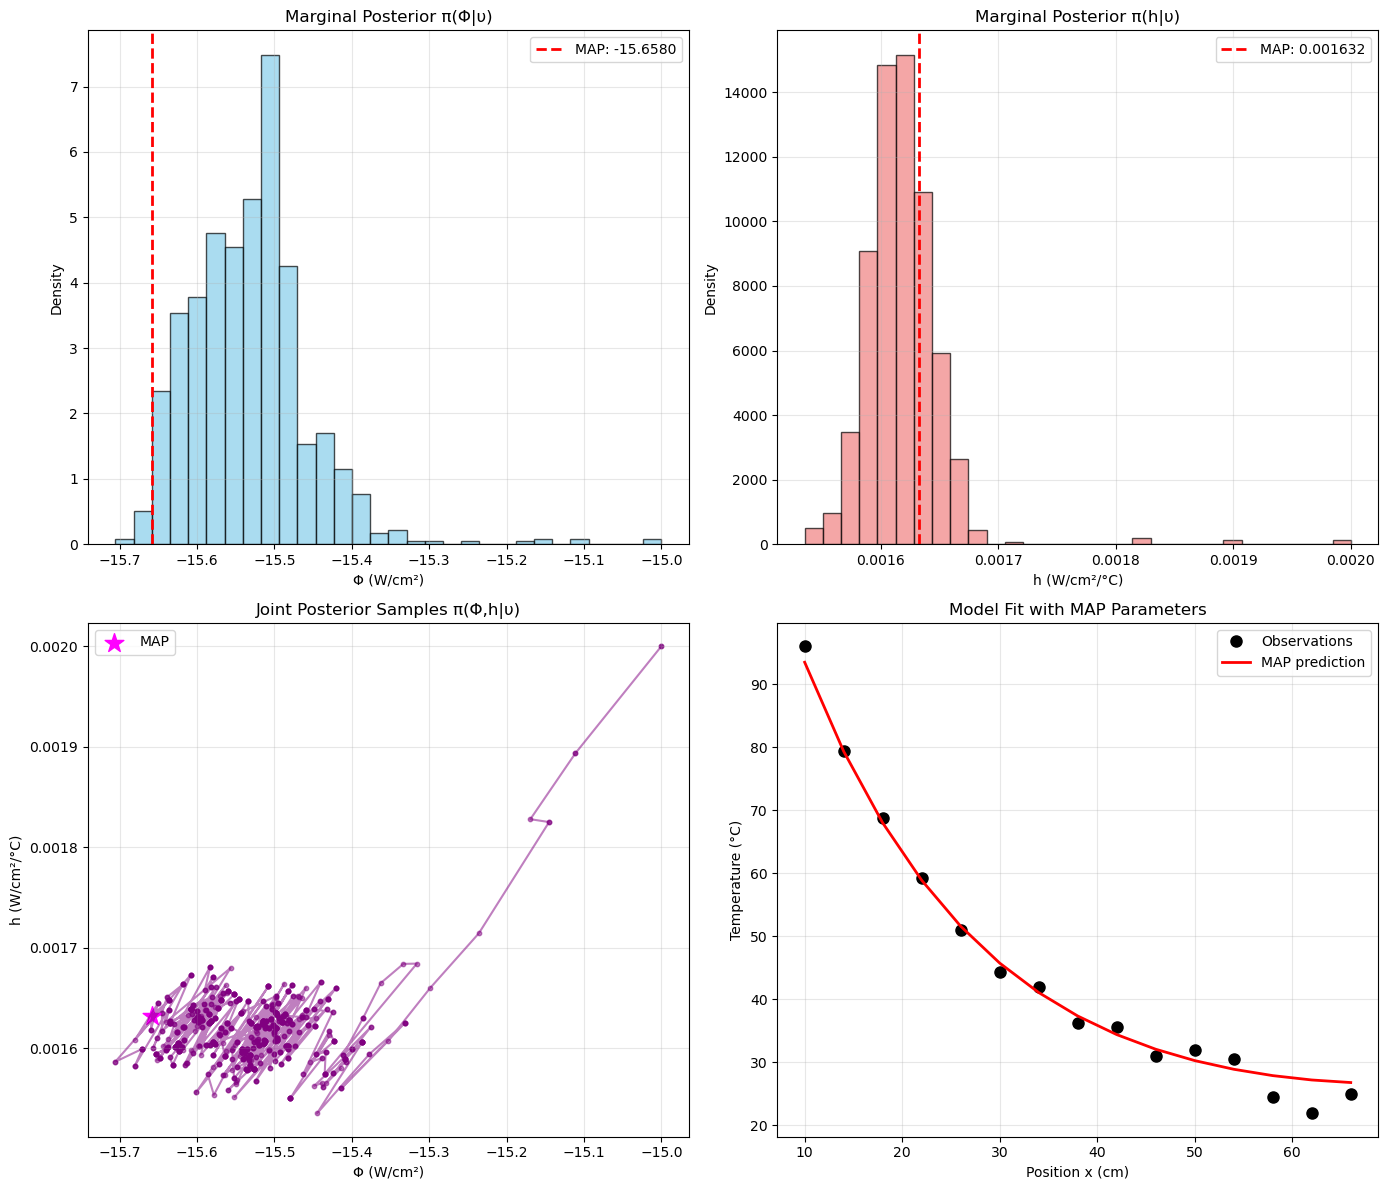

In [9]:

d4 = np.array([[1e-2, 1e-5],
                    [0, 2e-10]]) 
samples, q_map, posterior_values, acceptance_rate = run_metropolis_for_heat_equation(D = d4)

# Save results
np.savez('problem1.4_off_D.npz',
            samples=samples,
            q_map=q_map,
            posterior_values=posterior_values,
            acceptance_rate=acceptance_rate)


In manipulating the proposal covariance matrix D and initial guess $q_0$ for the Metropolis algorithm, we notice that the diagonal elements of D, which control the step sizes for Φ and h respectively, have a direct impact on the acceptance rate and mixing behavior of the chain. When D is too small, the proposal steps become very small, leading to high acceptance rates but extremely poor mixing—the chain explores the parameter space very slowly and exhibits high autocorrelation, requiring many more iterations to adequately sample the posterior distribution. Conversely, when D is too large, the proposals frequently land in regions of extremely low posterior probability, causing the acceptance rate to plummet and the chain to become "stuck" for long periods, again resulting in inefficient exploration. The optimal D balances these extremes, typically yielding acceptance rates between 20-40% and allowing the chain to explore the posterior efficiently. Regarding the initial guess $q_0$, starting far from the high-probability region (e.g., Φ = -5 or h = 0.01) simply extends the burn-in period as the chain must wander toward the posterior mode, but does not affect the final stationary distribution once convergence is achieved (as long as the extended burn-in is removed). 

The use of logarithms in the likelihood and prior calculations effectively prevents numerical underflow issues that could otherwise arise when multiplying many small probability densities, particularly when evaluating proposals far from the posterior mode. This logarithmic approach ensures numerical stability across a wide range of D values and initial conditions, allowing the algorithm to handle poor proposals without encountering floating-point precision limitations.

# 1.5

Shape of observations: (15,)
Initial test - r(q0, q0) = 1.000000

Running Metropolis algorithm for 100000 iterations...
Proposal distribution: N(q_prev, D) with D = diag([0.01, 2e-10])
Running Metropolis-Hastings MCMC...
  Completed 200/100000 iterations, acceptance rate: 0.719
  Completed 400/100000 iterations, acceptance rate: 0.759
  Completed 600/100000 iterations, acceptance rate: 0.783
  Completed 800/100000 iterations, acceptance rate: 0.796
  Completed 1000/100000 iterations, acceptance rate: 0.799
  Completed 1200/100000 iterations, acceptance rate: 0.808
  Completed 1400/100000 iterations, acceptance rate: 0.816
  Completed 1600/100000 iterations, acceptance rate: 0.821
  Completed 1800/100000 iterations, acceptance rate: 0.827
  Completed 2000/100000 iterations, acceptance rate: 0.822
  Completed 2200/100000 iterations, acceptance rate: 0.822
  Completed 2400/100000 iterations, acceptance rate: 0.821
  Completed 2600/100000 iterations, acceptance rate: 0.823
  Completed 2800

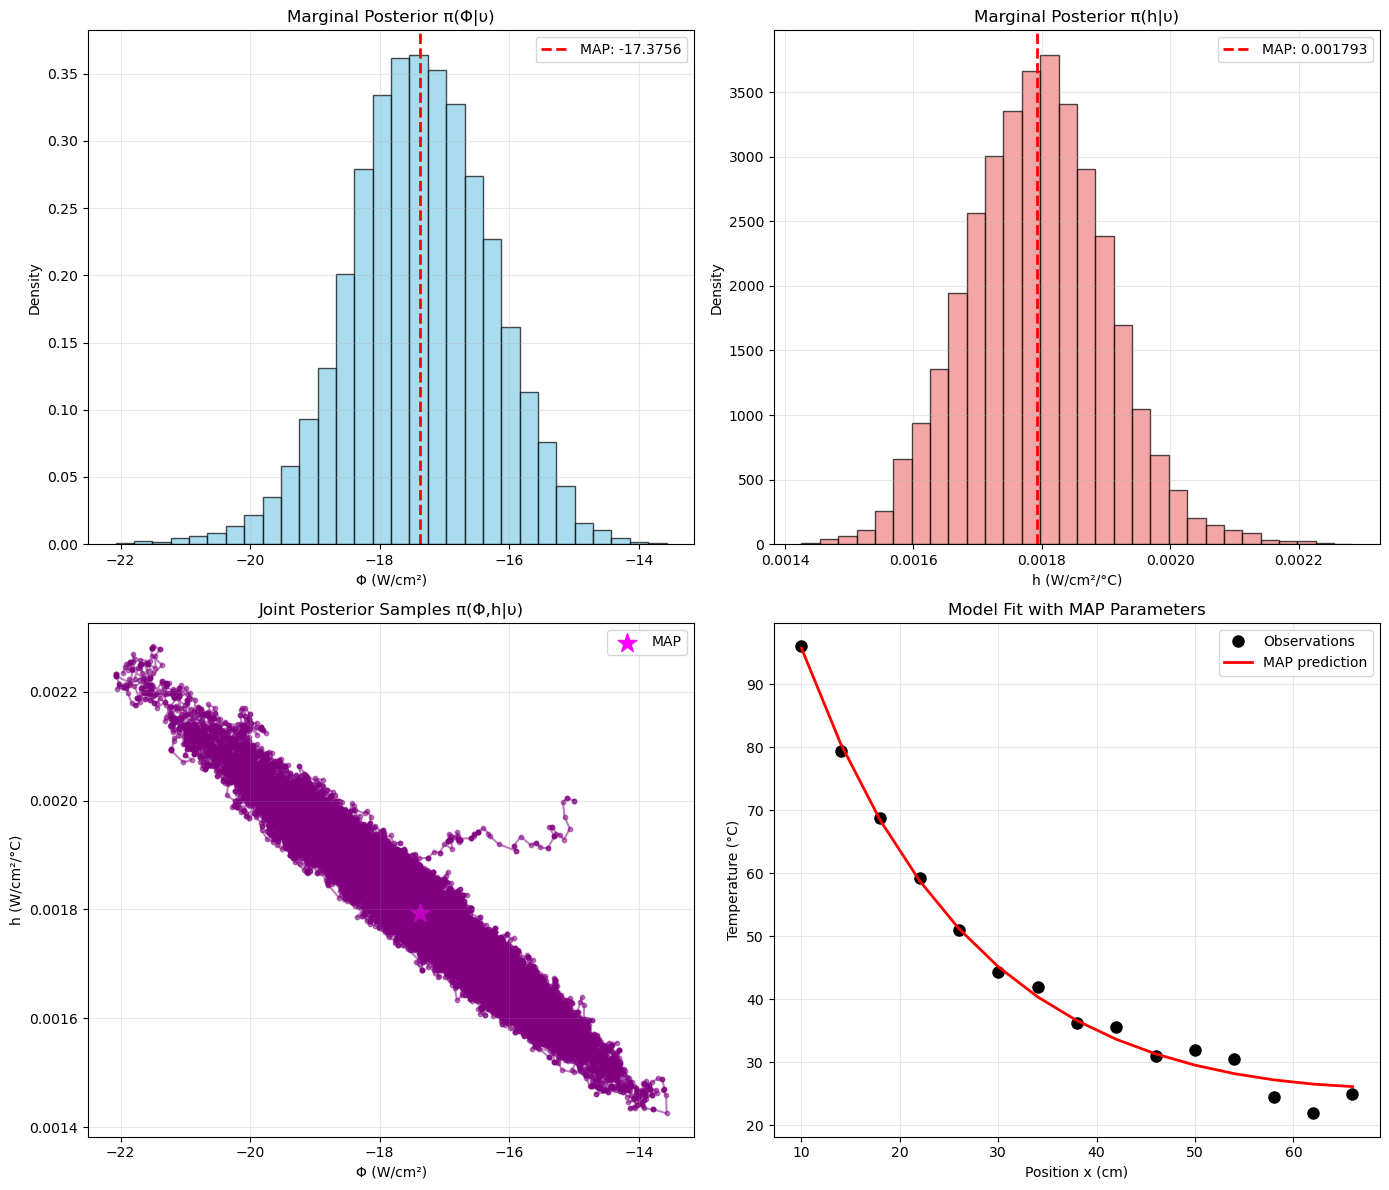

In [10]:

samples, q_map, posterior_values, acceptance_rate = run_metropolis_for_heat_equation(M = 100000)

# Save results
np.savez('problem1.5.npz',
            samples=samples,
            q_map=q_map,
            posterior_values=posterior_values,
            acceptance_rate=acceptance_rate)



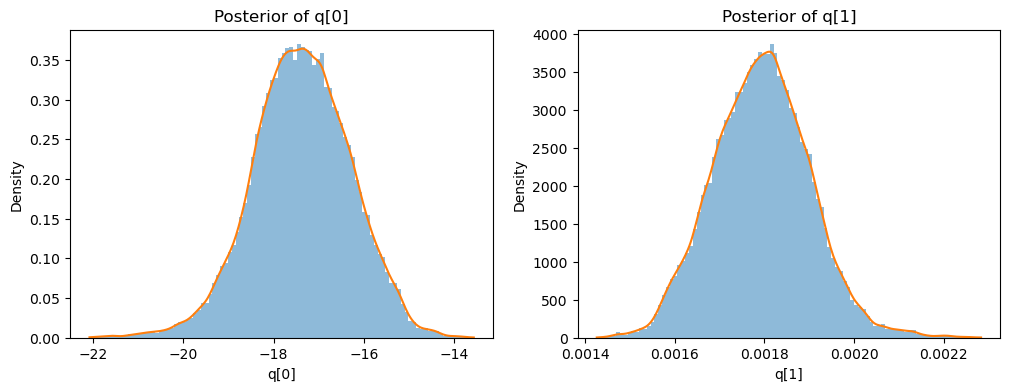

In [11]:
from scipy.stats import gaussian_kde
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(2):
    s = samples[:, i]
    
    # Histogram
    axes[i].hist(s, bins=100, density=True, alpha=0.5)
    
    # KDE smooth curve
    kde = gaussian_kde(s)
    x = np.linspace(min(s), max(s), 300)
    axes[i].plot(x, kde(x))
    
    axes[i].set_title(f"Posterior of q[{i}]")
    axes[i].set_xlabel(f"q[{i}]")
    axes[i].set_ylabel("Density")

Text(0.5, 1.0, 'Normalized Histogram for $\\Phi$')

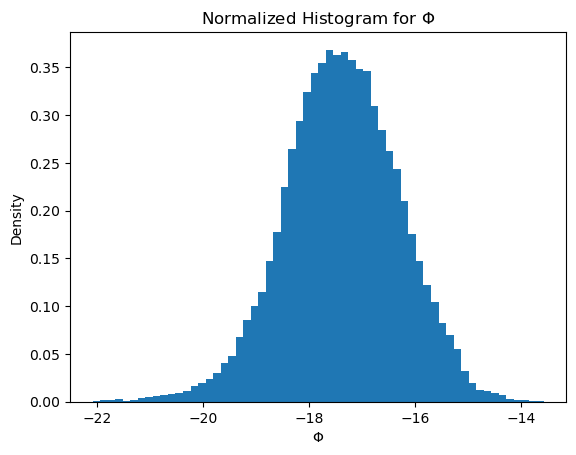

In [19]:
# Normalized histograms for phi, h
plt.hist(samples[:,0], density = True, bins = 60)
plt.xlabel(r"$\Phi$")
plt.ylabel(r"Density")
plt.title(r"Normalized Histogram for $\Phi$")


Text(0.5, 1.0, 'Normalized Histogram for $h$')

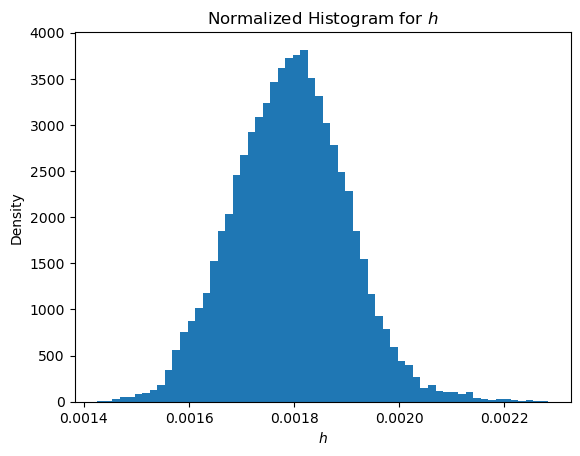

In [20]:

plt.hist(samples[:,1], density = True, bins = 60)
plt.xlabel(r"$h$")
plt.ylabel(r"Density")
plt.title(r"Normalized Histogram for $h$")

The new $q_{MAP} = [Φ = -17.375 W/cm², h = 0.00179 W/cm²/°C]$